## Load the Libraries

In [1]:
from google.colab import files
import pandas as pd
import numpy as np

## Import the file

In [2]:
uploaded = files.upload()

Saving clean_loans.csv to clean_loans.csv


In [3]:
df = pd.read_csv('clean_loans.csv')
df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,credit_score_bucket,dti_bucket,employment_tenure_flag
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,36,13.05,542.86,55.5,Paid Off,0,0,Poor,Very High,2 or more years
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,48,14.21,153.62,40.4,Default,138,1,Poor,High,2 or more years
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,36,12.37,1492.59,70.5,Paid Off,0,0,Poor,Very High,2 or more years
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,48,11.18,238.58,59.8,Default,34,1,Fair,Very High,2 or more years
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,36,9.66,359.61,44.1,Current,0,0,Good,High,2 or more years


In [4]:
# Check for missing values
print('Missing values')
print(df.isnull().sum())
# Check unique values in key columns
print("\nCredit Score Buckets:")
print(df['credit_score_bucket'].value_counts().sort_index())

print("\nDTI Buckets:")
print(df['dti_bucket'].value_counts().sort_index())


Missing values
borrower_id               0
age                       0
state                     0
education_level           0
employment_status         0
years_employed            0
annual_income             0
credit_score              0
home_ownership            0
dependents                0
existing_monthly_debt     0
loan_id                   0
application_date          0
loan_purpose              0
loan_ammount              0
term_months               0
interest_rate             0
monthly_payment           0
dti_ratio                 0
loan_status               0
days_delinquent           0
defaulted                 0
credit_score_bucket       0
dti_bucket                0
employment_tenure_flag    0
dtype: int64

Credit Score Buckets:
credit_score_bucket
Average       79
Excellent    231
Fair          93
Good          82
Poor         116
Name: count, dtype: int64

DTI Buckets:
dti_bucket
High         134
Low           48
Moderate     125
Unknown       23
Very High    271
Name: co

## 1.What is the overall default rate, and how does it break down by credit score range? Which credit score bucket has the highest default rate?

In [5]:
# Overall default rate
total_loans = len(df)
total_defaults = df['defaulted'].sum()
overall_default_rate = (total_defaults / total_loans) * 100

print("=" * 45)
print("        OVERALL DEFAULT RATE SUMMARY")
print("=" * 45)
print(f"  Total Loans Issued   : {total_loans}")
print(f"  Total Defaults       : {int(total_defaults)}")
print(f"  Non-Defaults         : {int(total_loans - total_defaults)}")
print(f"  Overall Default Rate : {overall_default_rate:.2f}%")
print(f"  Target Default Rate  : 12.00%")
print(f"  Variance from Target : +{overall_default_rate - 12:.2f}%")
print("=" * 45)

        OVERALL DEFAULT RATE SUMMARY
  Total Loans Issued   : 601
  Total Defaults       : 146
  Non-Defaults         : 455
  Overall Default Rate : 24.29%
  Target Default Rate  : 12.00%
  Variance from Target : +12.29%


In [6]:
# Default rate by credit score bucket
credit_score_analysis = df.groupby('credit_score_bucket').agg(
    Total_Loans    = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

# Calculate default rate per bucket
credit_score_analysis['Default_Rate_%'] = (
    credit_score_analysis['Total_Defaults'] /
    credit_score_analysis['Total_Loans'] * 100
).round(2)

# Sort by credit score bucket
credit_score_analysis = credit_score_analysis.sort_values('credit_score_bucket')

# Highlight the highest default rate bucket
highest_default_bucket = credit_score_analysis.loc[
    credit_score_analysis['Default_Rate_%'].idxmax()
]

print("\n" + "=" * 55)
print("       DEFAULT RATE BY CREDIT SCORE BUCKET")
print("=" * 55)
print(credit_score_analysis.to_string(index=False))
print("=" * 55)
print(f"\n  Highest Default Rate Bucket : {highest_default_bucket['credit_score_bucket']}")
print(f"   Default Rate                : {highest_default_bucket['Default_Rate_%']}%")
print(f"   Total Loans in Bucket       : {int(highest_default_bucket['Total_Loans'])}")
print(f"   Total Defaults in Bucket    : {int(highest_default_bucket['Total_Defaults'])}")


       DEFAULT RATE BY CREDIT SCORE BUCKET
credit_score_bucket  Total_Loans  Total_Defaults  Default_Rate_%
            Average           79              22           27.85
          Excellent          231              27           11.69
               Fair           93              27           29.03
               Good           82              13           15.85
               Poor          116              57           49.14

  Highest Default Rate Bucket : Poor
   Default Rate                : 49.14%
   Total Loans in Bucket       : 116
   Total Defaults in Bucket    : 57


/tmp/ipykernel_18238/357921498.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


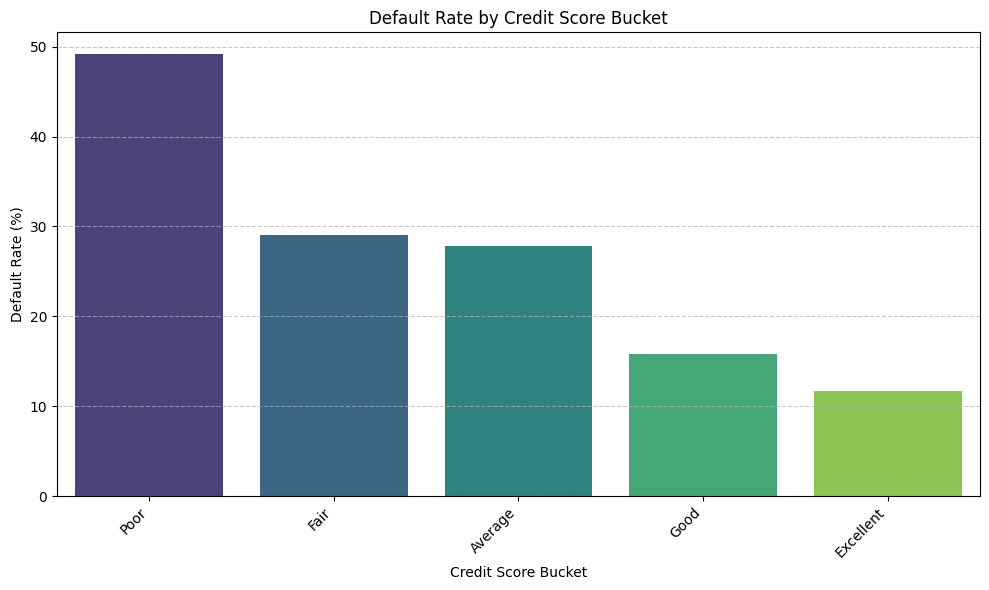

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='credit_score_bucket',
    y='Default_Rate_%',
    data=credit_score_analysis.sort_values(by='Default_Rate_%', ascending=False),
    palette='viridis'
)

plt.title('Default Rate by Credit Score Bucket')
plt.xlabel('Credit Score Bucket')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2.Is there a relationship between a borrower’s debt-to-income (DTI) ratio and the likelihood of defaulting? What DTI threshold would you recommend as a cutoff for loan approval?

In [8]:
# Default rate by DTI bucket
dti_analysis = df.groupby('dti_bucket').agg(
    Total_Loans    = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

# Calculate default rate per bucket
dti_analysis['Default_Rate_%'] = (
    dti_analysis['Total_Defaults'] /
    dti_analysis['Total_Loans'] * 100
).round(2)

# Sort by DTI bucket (low to high)
dti_analysis = dti_analysis.sort_values('dti_bucket')

# Highlight the highest default rate bucket
highest_dti_default = dti_analysis.loc[
    dti_analysis['Default_Rate_%'].idxmax()
]

print("=" * 55)
print("        DEFAULT RATE BY DTI BUCKET")
print("=" * 55)
print(dti_analysis.to_string(index=False))
print("=" * 55)
print(f"\n  Highest Default Rate Bucket : {highest_dti_default['dti_bucket']}")
print(f"   Default Rate                : {highest_dti_default['Default_Rate_%']}%")
print(f"   Total Loans in Bucket       : {int(highest_dti_default['Total_Loans'])}")
print(f"   Total Defaults in Bucket    : {int(highest_dti_default['Total_Defaults'])}")

        DEFAULT RATE BY DTI BUCKET
dti_bucket  Total_Loans  Total_Defaults  Default_Rate_%
      High          134              29           21.64
       Low           48               8           16.67
  Moderate          125              14           11.20
   Unknown           23               2            8.70
 Very High          271              93           34.32

  Highest Default Rate Bucket : Very High
   Default Rate                : 34.32%
   Total Loans in Bucket       : 271
   Total Defaults in Bucket    : 93


/tmp/ipykernel_18238/115385968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


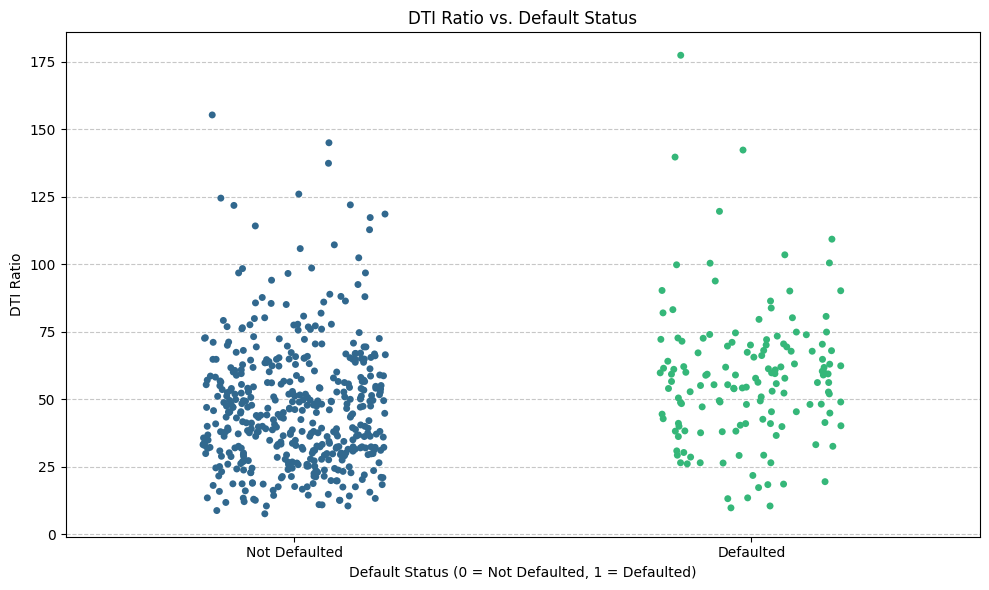

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a stripplot to visualize DTI ratio vs. default status
plt.figure(figsize=(10, 6))
sns.stripplot(
    x='defaulted',
    y='dti_ratio',
    data=df,
    jitter=0.2,
    palette='viridis' # Use a color palette
)

plt.title('DTI Ratio vs. Default Status')
plt.xlabel('Default Status (0 = Not Defaulted, 1 = Defaulted)')
plt.ylabel('DTI Ratio')
plt.xticks([0, 1], ['Not Defaulted', 'Defaulted'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3.Which loan purposes have the highest default rates, and does the average loan amount differ significantly between defaulted and non-defaulted loans?

In [10]:
loan_purpose_analysis = df.groupby('loan_purpose').agg(
    Total_Loans = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

loan_purpose_analysis['Default_Rate_%'] = (loan_purpose_analysis['Total_Defaults']
                                           /loan_purpose_analysis['Total_Loans'] * 100).round(2)
# Sort by default rate (highest first)
loan_purpose_analysis = loan_purpose_analysis.sort_values(
    'Default_Rate_%', ascending=False
).reset_index(drop=True)

# Highlight the highest default rate purpose
highest_purpose_default = loan_purpose_analysis.iloc[0]

print("=" * 55)
print("        DEFAULT RATE BY LOAN PURPOSE")
print("=" * 55)
print(loan_purpose_analysis.to_string(index=False))
print("=" * 55)
print(f"\n  Highest Default Rate Purpose : {highest_purpose_default['loan_purpose']}")
print(f"   Default Rate                 : {highest_purpose_default['Default_Rate_%']}%")
print(f"   Total Loans in Purpose       : {int(highest_purpose_default['Total_Loans'])}")
print(f"   Total Defaults in Purpose    : {int(highest_purpose_default['Total_Defaults'])}")

        DEFAULT RATE BY LOAN PURPOSE
      loan_purpose  Total_Loans  Total_Defaults  Default_Rate_%
           Wedding           56              18           32.14
  Home Improvement           70              20           28.57
         Auto Loan           59              16           27.12
     Business Loan           58              14           24.14
         Education           53              12           22.64
          Vacation           62              14           22.58
    Major Purchase           68              15           22.06
Debt Consolidation           51              11           21.57
            Moving           56              12           21.43
  Medical Expenses           68              14           20.59

  Highest Default Rate Purpose : Wedding
   Default Rate                 : 32.14%
   Total Loans in Purpose       : 56
   Total Defaults in Purpose    : 18


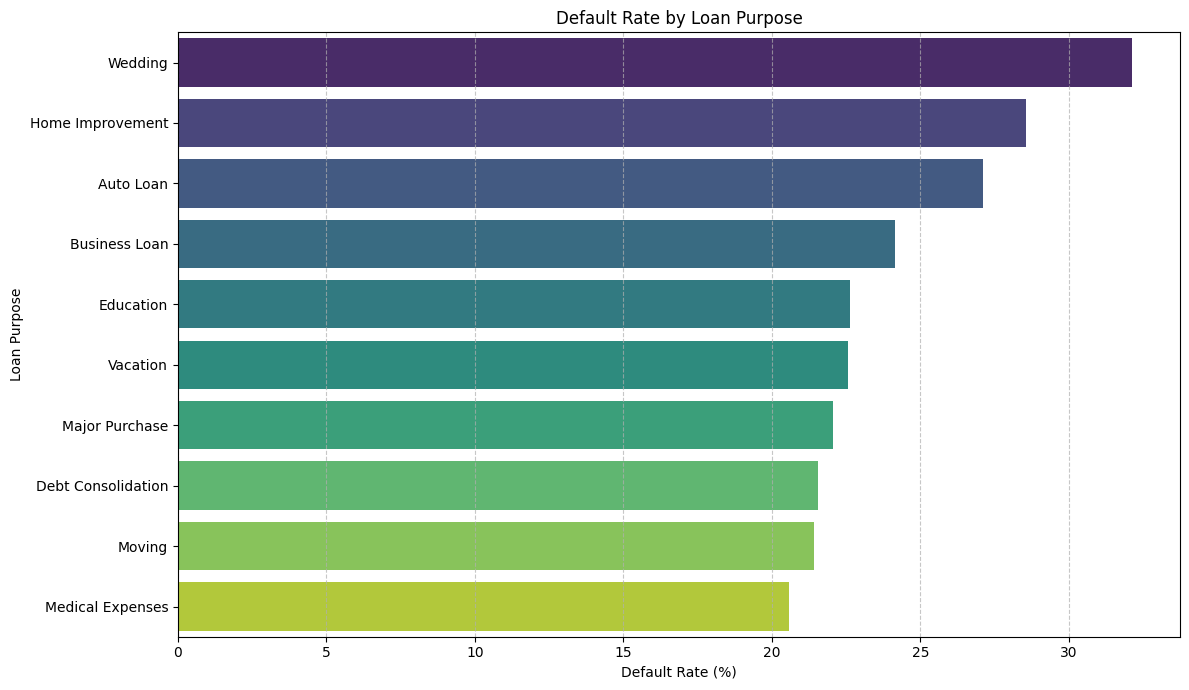

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot for default rate by loan purpose
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Default_Rate_%',
    y='loan_purpose',
    data=loan_purpose_analysis.sort_values(by='Default_Rate_%', ascending=False),
    palette='viridis',
    hue='loan_purpose', # Add hue parameter as suggested by the warning
    legend=False        # Set legend to False as hue is redundant with y-axis labels
)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# Compare average loan amount
loan_amount_comparison = df.groupby('defaulted')['loan_ammount'].agg(
    Average_Loan_Amount = 'mean',
    Loan_Count        = 'count'
).round(2)

# Add percentage difference
loan_amount_comparison['Pct_Diff_From_Non_Default'] = (
    (loan_amount_comparison.loc[1, 'Average_Loan_Amount'] -
     loan_amount_comparison.loc[0, 'Average_Loan_Amount']) /
    loan_amount_comparison.loc[0, 'Average_Loan_Amount'] * 100
).round(2)

print("\n" + "=" * 55)
print("        AVERAGE LOAN AMOUNT — DEFAULTED vs NON-DEFAULTED")
print("=" * 55)
print(loan_amount_comparison.to_string())
print("=" * 55)
print(f"\n Insight: Defaulted loans average ${loan_amount_comparison.loc[1, 'Average_Loan_Amount']:,.2f}")
print(f"         Non-defaulted loans average ${loan_amount_comparison.loc[0, 'Average_Loan_Amount']:,.2f}")
print(f"         Difference: {loan_amount_comparison.loc[1, 'Pct_Diff_From_Non_Default']:+.2f}%")


        AVERAGE LOAN AMOUNT — DEFAULTED vs NON-DEFAULTED
           Average_Loan_Amount  Loan_Count  Pct_Diff_From_Non_Default
defaulted                                                            
0                     22012.75         455                       2.53
1                     22570.55         146                       2.53

 Insight: Defaulted loans average $22,570.55
         Non-defaulted loans average $22,012.75
         Difference: +2.53%


## 4.How do employment status and years employed affect default risk? Are borrowers with less than 2 years of employment significantly more likely to default?

In [13]:
employment_analysis = df.groupby('employment_status').agg(
    Total_Loans = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

employment_analysis['Default_Rate_%'] = (employment_analysis['Total_Defaults'] /
                                         employment_analysis['Total_Loans'] * 100).round(2)

employment_analysis = employment_analysis.sort_values(
    'Default_Rate_%', ascending=False
).reset_index(drop=True)
# Highlight the highest default rate status
highest_employment_default = employment_analysis.iloc[0]

print("=" * 55)
print("        DEFAULT RATE BY EMPLOYMENT STATUS")
print("=" * 55)
print(employment_analysis.to_string(index=False))
print("=" * 55)
print(f"\n  Highest Default Rate Status : {highest_employment_default['employment_status']}")
print(f"   Default Rate                : {highest_employment_default['Default_Rate_%']}% ")
print(f"   Total Loans in Status       : {int(highest_employment_default['Total_Loans'])}")
print(f"   Total Defaults in Status    : {int(highest_employment_default['Total_Defaults'])}")

        DEFAULT RATE BY EMPLOYMENT STATUS
employment_status  Total_Loans  Total_Defaults  Default_Rate_%
        Part-Time           65              18           27.69
    Self-Employed          105              26           24.76
        Full-Time          305              73           23.93
          Retired           60              14           23.33
         Contract           66              15           22.73

  Highest Default Rate Status : Part-Time
   Default Rate                : 27.69% 
   Total Loans in Status       : 65
   Total Defaults in Status    : 18


/tmp/ipykernel_18238/2938762844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


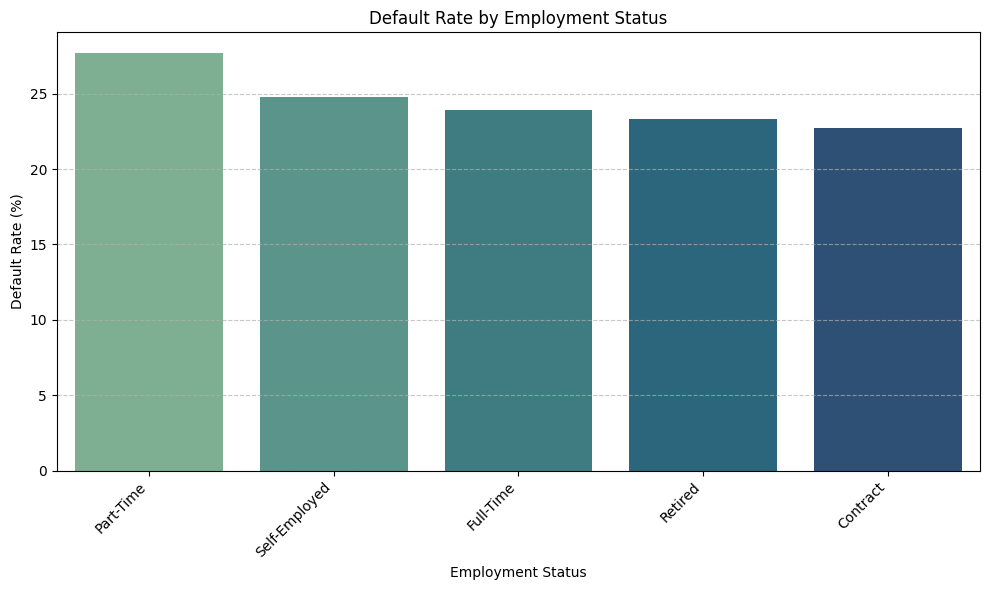

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot for default rate by employment status
plt.figure(figsize=(10, 6))
sns.barplot(
    x='employment_status',
    y='Default_Rate_%',
    data=employment_analysis.sort_values(by='Default_Rate_%', ascending=False),
    palette='crest'
)

plt.title('Default Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
# Default rate by employment tenure flag (created in SQL)
tenure_analysis = df.groupby('employment_tenure_flag').agg(
    Total_Loans    = ('defaulted', 'count'),
    Total_Defaults = ('defaulted', 'sum'),
).reset_index()

# Calculate default rate per tenure group
tenure_analysis['Default_Rate_%'] = (
    tenure_analysis['Total_Defaults'] /
    tenure_analysis['Total_Loans'] * 100
).round(2)

# Sort by Default_Rate_% in descending order to identify the higher risk group
tenure_analysis = tenure_analysis.sort_values('Default_Rate_%', ascending=False)

# Highlight the group with higher default rate
higher_risk_group = tenure_analysis.iloc[0]

print("\n" + "=" * 55)
print("        DEFAULT RATE BY EMPLOYMENT TENURE")
print("=" * 55)
print(tenure_analysis.to_string(index=False))
print("=" * 55)
print(f"\n Higher Risk Group           : {higher_risk_group['employment_tenure_flag']}")
print(f"   Default Rate                : {higher_risk_group['Default_Rate_%']}% ")
print(f"   Total Loans in Group        : {int(higher_risk_group['Total_Loans'])}")
print(f"   Total Defaults in Group     : {int(higher_risk_group['Total_Defaults'])}")

# Calculate the difference in default rates
less_than_2 = tenure_analysis[tenure_analysis['employment_tenure_flag'] == 'Less than 2 years'] ['Default_Rate_%'].iloc[0]
two_or_more = tenure_analysis[tenure_analysis['employment_tenure_flag'] == '2 or more years'] ['Default_Rate_%'].iloc[0]
difference = less_than_2 - two_or_more

print(f"\n Difference in Default Rate: +{difference:.2f}% (Less than 2 years vs 2+ years)")


        DEFAULT RATE BY EMPLOYMENT TENURE
employment_tenure_flag  Total_Loans  Total_Defaults  Default_Rate_%
     Less than 2 years           84              29           34.52
       2 or more years          517             117           22.63

 Higher Risk Group           : Less than 2 years
   Default Rate                : 34.52% 
   Total Loans in Group        : 84
   Total Defaults in Group     : 29

 Difference in Default Rate: +11.89% (Less than 2 years vs 2+ years)


## Summary of Key Default Risk Factors and Recommendations

Based on the analysis, the following three factors emerged as significant indicators of higher default risk:

1.  **Credit Score:** Borrowers with a **'Poor' credit score** showed the highest default rate at **49.14%**.
    *   **Recommendation:** Loans to applicants with a 'Poor' credit score should be critically reviewed, and consideration should be given to **setting a minimum credit score threshold, possibly excluding 'Poor' rated applicants**.

2.  **Debt-to-Income (DTI) Ratio:** Loans to applicants in the **'Very High' DTI bucket** experienced a **34.32%** default rate.
    *   **Recommendation:** Implement a strict **maximum DTI ratio threshold for loan approval**, ideally below the 'Very High' category to mitigate risk. A DTI **below 40%** would significantly reduce the likelihood of default, as 'High' and 'Moderate' categories have lower default rates.

3.  **Employment Tenure:** Borrowers with **less than 2 years of employment** history had a default rate of **34.52%**, significantly higher than those with 2 or more years (22.63%).
    *   **Recommendation:** Favor applicants with **at least 2 years of stable employment**. For those with less than 2 years, consider additional stringent requirements or a lower loan amount/higher interest rate to offset the increased risk.